# Chuấn bị dữ liệu

In [1]:
import pandas as pd

file_path = "/content/train.csv"
df = pd.read_csv(file_path)

print("=== Thông tin DataFrame ===")
print(df.info())

print("\n=== Thống kê numeric ===")
print(df.describe())

print("\n=== Thống kê toàn bộ cột ===")
print(df.describe(include='all'))

print("\n=== Số lượng missing values ===")
print(df.isnull().sum())

=== Thông tin DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070006 entries, 0 to 1070005
Data columns (total 36 columns):
 #   Column                                   Non-Null Count    Dtype  
---  ------                                   --------------    -----  
 0   Type                                     1070006 non-null  object 
 1   Prefecture                               1070006 non-null  object 
 2   TotalTransactionValue                    1070006 non-null  int64  
 3   Area                                     1070006 non-null  int64  
 4   Frontage                                 1070006 non-null  float64
 5   TotalFloorArea                           1070006 non-null  int64  
 6   ConstructionYear                         1070006 non-null  int64  
 7   BuildingCoverageRatio                    1070006 non-null  float64
 8   FloorAreaRatio                           1070006 non-null  float64
 9   Quarter                                  1070006 non-null  int

Feature engineer: tạo cột tuổi nhà dựa trên year và construction year


In [2]:
df['house_age'] = df['Year'] - df['ConstructionYear']
df['house_age'] = df['house_age'].clip(lower=0)

df.drop(columns=['ConstructionYear'], inplace=True)
print(df.head())

                                  Type            Prefecture  \
0  Residential Land(Land and Building)              Hokkaido   
1  Residential Land(Land and Building)     Miyagi Prefecture   
2  Residential Land(Land and Building)    Saitama Prefecture   
3  Residential Land(Land and Building)  Fukushima Prefecture   
4  Residential Land(Land and Building)   Shizuoka Prefecture   

   TotalTransactionValue  Area  Frontage  TotalFloorArea  \
0               27000000   200       9.0             100   
1               28000000   165       3.0             105   
2               19000000   145      12.5             105   
3               21000000   200      12.5             120   
4               43000000   240      12.0             115   

   BuildingCoverageRatio  FloorAreaRatio  Quarter  Year  ...  Region_Shikoku  \
0                   60.0           200.0        2  2023  ...           False   
1                   60.0           200.0        1  2014  ...           False   
2             

In [3]:
non_numeric_cols = df.select_dtypes(exclude='number').columns
print("Các cột không phải số:", list(non_numeric_cols))

Các cột không phải số: ['Type', 'Prefecture', 'RegionCommercialArea', 'RegionIndustrialArea', 'RegionPotentialResidentialArea', 'RegionResidentialArea', 'Region_Chubu', 'FloorAreaGreaterFLag', 'BeforeWarFlag', 'frontage_greater_than_50', 'AreaGreaterFlag', 'Region_Chugoku', 'Region_Hokkaido', 'Region_Kansai', 'Region_Kanto', 'Region_Kyushu', 'Region_Shikoku', 'Region_Tohoku']


In [ ]:
df.head(20)

,Type,Prefecture,TotalTransactionValue,Area,Frontage,TotalFloorArea,BuildingCoverageRatio,FloorAreaRatio,Quarter,Year,...,Region_Shikoku,Region_Tohoku,Migration,GDP_Deflator_Change_pct,RealGDP_Growth_pct,PrivateResidentialInvestment_Growth_pct,GovernmentConsumption_Growth_pct,HouseholdDisposableIncome_TrillionYen,RealEstate_Share_pct,house_age
0,Residential Land(Land and Building),Hokkaido,27000000,200,9.0,100,60.0,200.0,2,2023,...,False,False,2860.0,4.7,0.0,1.8,-0.8,319.1,12.8,1
1,Residential Land(Land and Building),Miyagi Prefecture,28000000,165,3.0,105,60.0,200.0,1,2014,...,False,True,27051.0,2.5,0.3,-7.0,0.9,288.5,13.2,1
2,Residential Land(Land and Building),Saitama Prefecture,19000000,145,12.5,105,50.0,80.0,3,2015,...,False,False,9979.0,1.6,1.8,2.3,1.9,293.1,12.9,0
3,Residential Land(Land and Building),Fukushima Prefecture,21000000,200,12.5,120,60.0,200.0,4,2010,...,False,True,23475.0,-1.7,3.4,5.0,2.6,289.5,12.8,1
4,Residential Land(Land and Building),Shizuoka Prefecture,43000000,240,12.0,115,60.0,200.0,2,2021,...,False,False,1166.0,0.1,3.9,0.7,3.8,310.8,12.9,0
5,Residential Land(Land and Building),Other,7100000,1200,31.5,520,70.0,200.0,3,2017,...,True,False,2508.0,0.2,1.8,-1.8,0.5,295.2,12.5,50
6,Residential Land(Land and Building),Chiba Prefecture,25000000,100,2.5,90,60.0,200.0,3,2007,...,False,False,53769.0,-1.0,1.2,-11.8,1.7,297.1,12.3,0
7,Residential Land(Land and Building),Other,6000000,195,10.0,105,60.0,200.0,2,2007,...,True,False,30802.0,-1.0,1.2,-11.8,1.7,297.1,12.3,7
8,Residential Land(Land and Building),Tokyo,33000000,100,6.6,80,40.0,80.0,4,2020,...,False,False,12320.0,0.9,-3.8,-6.3,2.6,315.5,12.7,0
9,Residential Land(Land and Building),Saitama Prefecture,3500000,50,7.8,65,50.0,80.0,2,2023,...,False,False,30059.0,4.7,0.0,1.8,-0.8,319.1,12.8,40


Xóa cột type do toàn data chỉ có 1 type

In [4]:
if 'Type' in df.columns:
    df.drop(columns=['Type'], inplace=True)

# Kiểm tra lại
print(df.head())
print("Các cột còn lại:", list(df.columns))

             Prefecture  TotalTransactionValue  Area  Frontage  \
0              Hokkaido               27000000   200       9.0   
1     Miyagi Prefecture               28000000   165       3.0   
2    Saitama Prefecture               19000000   145      12.5   
3  Fukushima Prefecture               21000000   200      12.5   
4   Shizuoka Prefecture               43000000   240      12.0   

   TotalFloorArea  BuildingCoverageRatio  FloorAreaRatio  Quarter  Year  \
0             100                   60.0           200.0        2  2023   
1             105                   60.0           200.0        1  2014   
2             105                   50.0            80.0        3  2015   
3             120                   60.0           200.0        4  2010   
4             115                   60.0           200.0        2  2021   

   RegionCommercialArea  ...  Region_Shikoku  Region_Tohoku  Migration  \
0                 False  ...           False          False     2860.0   
1   

Mã hóa trên tập train


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, OneHotEncoder


# 1. Xử lý Quarter: cyclic encoding
if 'Quarter' in df.columns:
    df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter'] / 4)
    df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter'] / 4)
    df.drop(columns=['Quarter'], inplace=True)

# 2. One-Hot Encoding Prefecture
ohe_pref = OneHotEncoder(sparse_output=False, dtype=int)
pref_encoded = ohe_pref.fit_transform(df[['Prefecture']])
pref_cols = [f'Prefecture_{c}' for c in ohe_pref.categories_[0]]
df_pref = pd.DataFrame(pref_encoded, columns=pref_cols, index=df.index)
df = pd.concat([df.drop(columns=['Prefecture']), df_pref], axis=1)

# 3. Log transform target
df['TotalTransactionValue_log'] = np.log1p(df['TotalTransactionValue'])
target_col = 'TotalTransactionValue_log'

# 4. Chuẩn hóa các cột numeric khác
numeric_cols = [
    'Area', 'Frontage', 'TotalFloorArea',
    'BuildingCoverageRatio', 'FloorAreaRatio', 'AverageTimeToStation',
    'Migration', 'GDP_Deflator_Change_pct', 'RealGDP_Growth_pct',
    'PrivateResidentialInvestment_Growth_pct', 'GovernmentConsumption_Growth_pct',
    'HouseholdDisposableIncome_TrillionYen', 'RealEstate_Share_pct', 'house_age', 'Year'
]

scaler = RobustScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print(df[[target_col] + numeric_cols].head())
print("Các cột hiện tại:", list(df.columns))

   TotalTransactionValue_log      Area  Frontage  TotalFloorArea  \
0                  17.111347  0.391304 -0.212121       -0.166667   
1                  17.147715  0.086957 -1.121212        0.000000   
2                  16.759950 -0.086957  0.318182        0.000000   
3                  16.860033  0.391304  0.318182        0.500000   
4                  17.576711  0.739130  0.242424        0.333333   

   BuildingCoverageRatio  FloorAreaRatio  AverageTimeToStation  Migration  \
0                    0.0             0.0             -0.371429  -0.675096   
1                    0.0             0.0              0.142857   0.629212   
2                   -1.0            -1.2              0.057143  -0.291260   
3                    0.0             0.0              0.771429   0.436405   
4                    0.0             0.0             -0.457143  -0.766431   

   GDP_Deflator_Change_pct  RealGDP_Growth_pct  \
0                 2.368421           -0.333333   
1                 1.210526  

Tập test làm tương tự train từ bước chuẩn bị dữ liệu với mã hóa

In [6]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import RobustScaler, OneHotEncoder

df_test = pd.read_csv("/content/test.csv")
df_test['house_age'] = (df_test['Year'] - df_test['ConstructionYear']).clip(lower=0)
df_test.drop(columns=['ConstructionYear'], inplace=True)
if 'Type' in df_test.columns:
    df_test.drop(columns=['Type'], inplace=True)

# -----------------------------
# 1. Quarter cyclic encoding
# -----------------------------
df_test['Quarter_sin'] = np.sin(2 * np.pi * df_test['Quarter'] / 4)
df_test['Quarter_cos'] = np.cos(2 * np.pi * df_test['Quarter'] / 4)
df_test.drop(columns=['Quarter'], inplace=True)
pref_encoded_test = ohe_pref.transform(df_test[['Prefecture']])
df_pref_test = pd.DataFrame(pref_encoded_test, columns=pref_cols, index=df_test.index)
df_test = pd.concat([df_test.drop(columns=['Prefecture']), df_pref_test], axis=1)
if 'TotalTransactionValue' in df_test.columns:
    df_test['TotalTransactionValue_log'] = np.log1p(df_test['TotalTransactionValue'])
    target_col = 'TotalTransactionValue_log'
numeric_cols = [
    'Area', 'Frontage', 'TotalFloorArea',
    'BuildingCoverageRatio', 'FloorAreaRatio', 'AverageTimeToStation',
    'Migration', 'GDP_Deflator_Change_pct', 'RealGDP_Growth_pct',
    'PrivateResidentialInvestment_Growth_pct', 'GovernmentConsumption_Growth_pct',
    'HouseholdDisposableIncome_TrillionYen', 'RealEstate_Share_pct', 'house_age', 'Year'
]
df_test[numeric_cols] = scaler.transform(df_test[numeric_cols])

print(df_test.head())
print("Các cột hiện tại:", list(df_test.columns))


   TotalTransactionValue      Area  Frontage  TotalFloorArea  \
0               70000000  5.782609  2.378788        1.166667   
1               27000000  0.130435  0.090909        0.000000   
2               27000000 -0.086957 -0.060606       -0.333333   
3               47000000  0.826087  0.696970        5.166667   
4               43000000 -0.521739  0.363636        0.333333   

   BuildingCoverageRatio  FloorAreaRatio   Year  RegionCommercialArea  \
0                    0.0             0.0 -0.250                 False   
1                   -1.0            -1.0  0.500                 False   
2                    0.0             0.0  0.625                 False   
3                    0.0             1.0 -0.875                 False   
4                    0.0             0.0  0.375                 False   

   RegionIndustrialArea  RegionPotentialResidentialArea  ...  \
0                 False                           False  ...   
1                 False                         

Đổi tên target cho không nhầm


In [7]:
df['TotalTransactionValue_log'] = np.log1p(df['TotalTransactionValue'])
df.drop(columns=['TotalTransactionValue'], inplace=True)

if 'TotalTransactionValue' in df_test.columns:
    df_test['TotalTransactionValue_log'] = np.log1p(df_test['TotalTransactionValue'])
    df_test.drop(columns=['TotalTransactionValue'], inplace=True)

In [8]:
df.head()

,Area,Frontage,TotalFloorArea,BuildingCoverageRatio,FloorAreaRatio,Year,RegionCommercialArea,RegionIndustrialArea,RegionPotentialResidentialArea,RegionResidentialArea,...,Prefecture_Niigata Prefecture,Prefecture_Okayama Prefecture,Prefecture_Osaka Prefecture,Prefecture_Other,Prefecture_Saitama Prefecture,Prefecture_Shiga Prefecture,Prefecture_Shizuoka Prefecture,Prefecture_Tochigi Prefecture,Prefecture_Tokyo,TotalTransactionValue_log
0,0.391304,-0.212121,-0.166667,0.0,0.0,0.875,False,False,False,True,...,0,0,0,0,0,0,0,0,0,17.111347
1,0.086957,-1.121212,0.000000,0.0,0.0,-0.250,False,False,False,True,...,0,0,0,0,0,0,0,0,0,17.147715
2,-0.086957,0.318182,0.000000,-1.0,-1.2,-0.125,False,False,False,True,...,0,0,0,0,1,0,0,0,0,16.759950
3,0.391304,0.318182,0.500000,0.0,0.0,-0.750,False,False,False,True,...,0,0,0,0,0,0,0,0,0,16.860033
4,0.739130,0.242424,0.333333,0.0,0.0,0.625,False,False,False,True,...,0,0,0,0,0,0,1,0,0,17.576711


Kiểm tra lại các cột

In [9]:
print(df.columns)

Index(['Area', 'Frontage', 'TotalFloorArea', 'BuildingCoverageRatio',
       'FloorAreaRatio', 'Year', 'RegionCommercialArea',
       'RegionIndustrialArea', 'RegionPotentialResidentialArea',
       'RegionResidentialArea', 'MunicipalityCategory', 'Region_Chubu',
       'AverageTimeToStation', 'FloorAreaGreaterFLag', 'BeforeWarFlag',
       'frontage_greater_than_50', 'AreaGreaterFlag', 'Region_Chugoku',
       'Region_Hokkaido', 'Region_Kansai', 'Region_Kanto', 'Region_Kyushu',
       'Region_Shikoku', 'Region_Tohoku', 'Migration',
       'GDP_Deflator_Change_pct', 'RealGDP_Growth_pct',
       'PrivateResidentialInvestment_Growth_pct',
       'GovernmentConsumption_Growth_pct',
       'HouseholdDisposableIncome_TrillionYen', 'RealEstate_Share_pct',
       'house_age', 'Quarter_sin', 'Quarter_cos',
       'Prefecture_Aichi Prefecture', 'Prefecture_Chiba Prefecture',
       'Prefecture_Fukuoka Prefecture', 'Prefecture_Fukushima Prefecture',
       'Prefecture_Gifu Prefecture', 'Prefectu

In [10]:
df.head()

,Area,Frontage,TotalFloorArea,BuildingCoverageRatio,FloorAreaRatio,Year,RegionCommercialArea,RegionIndustrialArea,RegionPotentialResidentialArea,RegionResidentialArea,...,Prefecture_Niigata Prefecture,Prefecture_Okayama Prefecture,Prefecture_Osaka Prefecture,Prefecture_Other,Prefecture_Saitama Prefecture,Prefecture_Shiga Prefecture,Prefecture_Shizuoka Prefecture,Prefecture_Tochigi Prefecture,Prefecture_Tokyo,TotalTransactionValue_log
0,0.391304,-0.212121,-0.166667,0.0,0.0,0.875,False,False,False,True,...,0,0,0,0,0,0,0,0,0,17.111347
1,0.086957,-1.121212,0.000000,0.0,0.0,-0.250,False,False,False,True,...,0,0,0,0,0,0,0,0,0,17.147715
2,-0.086957,0.318182,0.000000,-1.0,-1.2,-0.125,False,False,False,True,...,0,0,0,0,1,0,0,0,0,16.759950
3,0.391304,0.318182,0.500000,0.0,0.0,-0.750,False,False,False,True,...,0,0,0,0,0,0,0,0,0,16.860033
4,0.739130,0.242424,0.333333,0.0,0.0,0.625,False,False,False,True,...,0,0,0,0,0,0,1,0,0,17.576711


Kiểm tra xem test và train có đồng bộ cột chưa

In [11]:
df_train_copy = df.copy()
df_test_copy = df_test.copy()
print("Cột còn lại df_train_copy:", list(df_train_copy.columns))
print("Cột còn lại df_test_copy:", list(df_test_copy.columns))

Cột còn lại df_train_copy: ['Area', 'Frontage', 'TotalFloorArea', 'BuildingCoverageRatio', 'FloorAreaRatio', 'Year', 'RegionCommercialArea', 'RegionIndustrialArea', 'RegionPotentialResidentialArea', 'RegionResidentialArea', 'MunicipalityCategory', 'Region_Chubu', 'AverageTimeToStation', 'FloorAreaGreaterFLag', 'BeforeWarFlag', 'frontage_greater_than_50', 'AreaGreaterFlag', 'Region_Chugoku', 'Region_Hokkaido', 'Region_Kansai', 'Region_Kanto', 'Region_Kyushu', 'Region_Shikoku', 'Region_Tohoku', 'Migration', 'GDP_Deflator_Change_pct', 'RealGDP_Growth_pct', 'PrivateResidentialInvestment_Growth_pct', 'GovernmentConsumption_Growth_pct', 'HouseholdDisposableIncome_TrillionYen', 'RealEstate_Share_pct', 'house_age', 'Quarter_sin', 'Quarter_cos', 'Prefecture_Aichi Prefecture', 'Prefecture_Chiba Prefecture', 'Prefecture_Fukuoka Prefecture', 'Prefecture_Fukushima Prefecture', 'Prefecture_Gifu Prefecture', 'Prefecture_Gunma Prefecture', 'Prefecture_Hiroshima Prefecture', 'Prefecture_Hokkaido', 'Pre

#tương quan giữ các feature vs nhau và target vs feature

Top 10 feature tương quan mạnh nhất với TotalTransactionValue:
Migration                         0.364439
TotalFloorArea                    0.319968
Prefecture_Tokyo                  0.281341
Region_Kanto                      0.245685
MunicipalityCategory              0.245107
Prefecture_Kanagawa Prefecture    0.160301
FloorAreaGreaterFLag              0.119313
RegionCommercialArea              0.094681
Prefecture_Aichi Prefecture       0.090270
AreaGreaterFlag                   0.057451
Name: TotalTransactionValue_log, dtype: float64


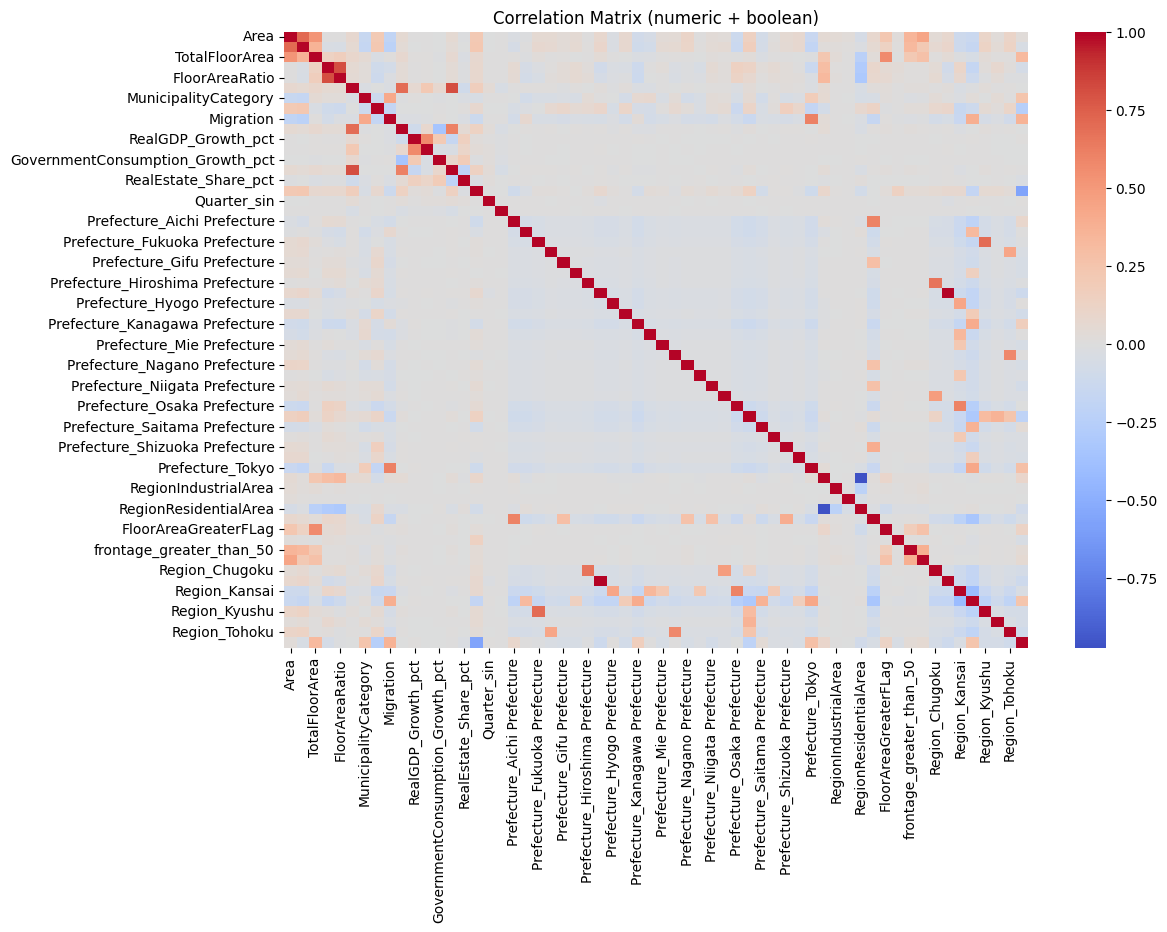

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


bool_cols = df_train_copy.select_dtypes(include='bool').columns.tolist()

numeric_cols = [col for col in df_train_copy.columns
                if col not in bool_cols + ['TotalTransactionValue_log'] and not col.startswith('cluster')]
features = numeric_cols + bool_cols

#Convert tất cả boolean sang 0/1
df_train_copy[bool_cols] = df_train_copy[bool_cols].astype(int)

#Tính ma trận tương quan
cols_to_corr = features + ['TotalTransactionValue_log']
corr_matrix = df_train_copy[cols_to_corr].corr()

#Tương quan với target
target_corr = corr_matrix['TotalTransactionValue_log'].sort_values(ascending=False)
print("Top 10 feature tương quan mạnh nhất với TotalTransactionValue:")
print(target_corr[1:11])

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix (numeric + boolean)")
plt.show()

Kiểm tra các cặp có tương quan cao

In [ ]:
import numpy as np

cols = numeric_cols + bool_cols
corr_matrix = df_train_copy[cols].corr().abs()

strong_pairs = np.where(corr_matrix > 0.6)
already_seen = set()
for i, j in zip(*strong_pairs):
    if i != j and (j, i) not in already_seen:
        print(f"{cols[i]} ↔ {cols[j]}: {corr_matrix.iloc[i, j]:.2f}")
        already_seen.add((i, j))

Area ↔ Frontage: 0.71
BuildingCoverageRatio ↔ FloorAreaRatio: 0.81
Year ↔ GDP_Deflator_Change_pct: 0.69
Year ↔ HouseholdDisposableIncome_TrillionYen: 0.81
Migration ↔ Prefecture_Tokyo: 0.61
GDP_Deflator_Change_pct ↔ HouseholdDisposableIncome_TrillionYen: 0.61
Prefecture_Fukuoka Prefecture ↔ Region_Kyushu: 0.70
Prefecture_Hiroshima Prefecture ↔ Region_Chugoku: 0.67
Prefecture_Hokkaido ↔ Region_Hokkaido: 1.00
RegionCommercialArea ↔ RegionResidentialArea: 0.97


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Drop cột tương quan mạnh và cột dự đoán trên 0.85
drop_cols = ['RegionResidentialArea', 'Prefecture_Hokkaido', 'GDP_Deflator_Change_pct']

drop_cols_train = list(set(drop_cols) & set(df_train_copy.columns))
drop_cols_test  = list(set(drop_cols) & set(df_test_copy.columns))

df_train_final = df_train_copy.drop(columns=drop_cols_train)
df_test_final  = df_test_copy.drop(columns=drop_cols_test)


In [ ]:
import xgboost as xgb
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

# =========================
# 1. Xác định target và features
# =========================
target = 'TotalTransactionValue_log'
features = [col for col in df_train_final.columns if col != target]

X_train = df_train_final[features]
X_test = df_test_final[features]

# target log scale
y_train_log = df_train_final[target]
y_test_log = df_test_final[target]

# target original scale
y_train_real = np.expm1(y_train_log)
y_test_real = np.expm1(y_test_log)


# =========================
# 2. Hàm SMAPE
# =========================
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = np.abs(y_true) + np.abs(y_pred)

    return np.mean(
        2 * np.abs(y_pred - y_true) / (denominator + 1e-8)
    ) * 100


# =========================
# 3. Khởi tạo model
# =========================
models = {
    "LinearRegression": LinearRegression(),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=20)),
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=1000)),
    ]),

    "XGBoost_GPU": xgb.XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        device='cuda',
        random_state=42
    ),

    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=120,
            max_depth=18,
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42,
        )),
    ]),

    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=150,
            max_depth=20,
            min_samples_split=4,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42,
        )),
    ]),

    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
        )),
    ]),
}


# =========================
# 4. Train & Evaluate
# =========================
tolerances = [0.4, 0.3, 0.2, 0.1, 0.05]

for name, model in models.items():
    print(f"\n===== {name} =====")

    # ===== Train =====
    model.fit(X_train, y_train_log)

    # ===== Predict (log scale)
    train_pred_log = model.predict(X_train)
    test_pred_log = model.predict(X_test)

    # =========================
    # LOG SCALE METRICS
    # =========================
    rmse_train_log = np.sqrt(mean_squared_error(y_train_log, train_pred_log))
    rmse_test_log = np.sqrt(mean_squared_error(y_test_log, test_pred_log))

    mae_train_log = mean_absolute_error(y_train_log, train_pred_log)
    mae_test_log = mean_absolute_error(y_test_log, test_pred_log)

    r2_train_log = r2_score(y_train_log, train_pred_log)
    r2_test_log = r2_score(y_test_log, test_pred_log)

    print("Log scale:")
    print(f"  Train → RMSE: {rmse_train_log:.4f}, MAE: {mae_train_log:.4f}, R²: {r2_train_log:.4f}")
    print(f"  Test  → RMSE: {rmse_test_log:.4f}, MAE: {mae_test_log:.4f}, R²: {r2_test_log:.4f}")

    # =========================
    # ACCURACY ±% (LOG SCALE)
    # =========================
    for tol in tolerances:
        acc_train_log = np.mean(
            np.abs(train_pred_log - y_train_log) <= tol
        )

        acc_test_log = np.mean(
            np.abs(test_pred_log - y_test_log) <= tol
        )

        print(f"  Log Accuracy ±{int(tol*100)}% → Train: {acc_train_log:.4f}, Test: {acc_test_log:.4f}")

    # =========================
    # ORIGINAL SCALE
    # =========================
    train_pred_real = np.expm1(train_pred_log)
    test_pred_real = np.expm1(test_pred_log)

    rmse_train_real = np.sqrt(mean_squared_error(y_train_real, train_pred_real))
    rmse_test_real = np.sqrt(mean_squared_error(y_test_real, test_pred_real))

    mae_train_real = mean_absolute_error(y_train_real, train_pred_real)
    mae_test_real = mean_absolute_error(y_test_real, test_pred_real)

    r2_train_real = r2_score(y_train_real, train_pred_real)
    r2_test_real = r2_score(y_test_real, test_pred_real)

    print("Original scale:")
    print(f"  Train → RMSE: {rmse_train_real:.2f}, MAE: {mae_train_real:.2f}, R²: {r2_train_real:.4f}")
    print(f"  Test  → RMSE: {rmse_test_real:.2f}, MAE: {mae_test_real:.2f}, R²: {r2_test_real:.4f}")

    # =========================
    # ACCURACY ±% (ORIGINAL SCALE)
    # =========================
    for tol in tolerances:
        lower_train = y_train_real * (1 - tol)
        upper_train = y_train_real * (1 + tol)

        lower_test = y_test_real * (1 - tol)
        upper_test = y_test_real * (1 + tol)

        acc_train = np.mean(
            (train_pred_real >= lower_train) &
            (train_pred_real <= upper_train)
        )

        acc_test = np.mean(
            (test_pred_real >= lower_test) &
            (test_pred_real <= upper_test)
        )

        print(f"  Accuracy ±{int(tol*100)}% → Train: {acc_train:.4f}, Test: {acc_test:.4f}")

    # =========================
    # SMAPE
    # =========================
    smape_train = smape(y_train_real, train_pred_real)
    smape_test = smape(y_test_real, test_pred_real)

    print(f"  SMAPE → Train: {smape_train:.4f}, Test: {smape_test:.4f}")

    print("-" * 60)


===== LinearRegression =====
Log scale:
  Train → RMSE: 0.5929, MAE: 0.4067, R²: 0.6342
  Test  → RMSE: 0.5915, MAE: 0.4058, R²: 0.6337
  Log Accuracy ±40% → Train: 0.6351, Test: 0.6357
  Log Accuracy ±30% → Train: 0.5149, Test: 0.5153
  Log Accuracy ±20% → Train: 0.3651, Test: 0.3654
  Log Accuracy ±10% → Train: 0.1901, Test: 0.1902
  Log Accuracy ±5% → Train: 0.0961, Test: 0.0962
Original scale:
  Train → RMSE: 92072987.61, MAE: 13465265.74, R²: -0.5407
  Test  → RMSE: 90304140.35, MAE: 13472440.69, R²: -0.8880
  Accuracy ±40% → Train: 0.6575, Test: 0.6574
  Accuracy ±30% → Train: 0.5285, Test: 0.5285
  Accuracy ±20% → Train: 0.3708, Test: 0.3708
  Accuracy ±10% → Train: 0.1909, Test: 0.1912
  Accuracy ±5% → Train: 0.0962, Test: 0.0962
  SMAPE → Train: 37.7113, Test: 37.6389
------------------------------------------------------------

===== Ridge =====
Log scale:
  Train → RMSE: 0.5929, MAE: 0.4067, R²: 0.6342
  Test  → RMSE: 0.5915, MAE: 0.4058, R²: 0.6337
  Log Accuracy ±40% → Tr

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [11:40:25] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Log scale:
  Train → RMSE: 0.4532, MAE: 0.2962, R²: 0.7862
  Test  → RMSE: 0.4681, MAE: 0.3029, R²: 0.7705
  Log Accuracy ±40% → Train: 0.7677, Test: 0.7619
  Log Accuracy ±30% → Train: 0.6626, Test: 0.6579
  Log Accuracy ±20% → Train: 0.5039, Test: 0.4996
  Log Accuracy ±10% → Train: 0.2780, Test: 0.2763
  Log Accuracy ±5% → Train: 0.1429, Test: 0.1416
Original scale:
  Train → RMSE: 41958138.29, MAE: 7606722.41, R²: 0.6801
  Test  → RMSE: 34042717.83, MAE: 7869991.58, R²: 0.7317
  Accuracy ±40% → Train: 0.7850, Test: 0.7794
  Accuracy ±30% → Train: 0.6759, Test: 0.6703
  Accuracy ±20% → Train: 0.5102, Test: 0.5066
  Accuracy ±10% → Train: 0.2791, Test: 0.2771
  Accuracy ±5% → Train: 0.1432, Test: 0.1416
  SMAPE → Train: 28.0461, Test: 28.5687
------------------------------------------------------------

===== RandomForest =====
Log scale:
  Train → RMSE: 0.4144, MAE: 0.2726, R²: 0.8213
  Test  → RMSE: 0.4901, MAE: 0.3174, R²: 0.7486
  Log Accuracy ±40% → Train: 0.7923, Test: 0.7452
 

In [14]:
print(df_train_final.columns)

Index(['Area', 'Frontage', 'TotalFloorArea', 'BuildingCoverageRatio',
       'FloorAreaRatio', 'Year', 'RegionCommercialArea',
       'RegionIndustrialArea', 'RegionPotentialResidentialArea',
       'MunicipalityCategory', 'Region_Chubu', 'AverageTimeToStation',
       'FloorAreaGreaterFLag', 'BeforeWarFlag', 'frontage_greater_than_50',
       'AreaGreaterFlag', 'Region_Chugoku', 'Region_Hokkaido', 'Region_Kansai',
       'Region_Kanto', 'Region_Kyushu', 'Region_Shikoku', 'Region_Tohoku',
       'Migration', 'RealGDP_Growth_pct',
       'PrivateResidentialInvestment_Growth_pct',
       'GovernmentConsumption_Growth_pct',
       'HouseholdDisposableIncome_TrillionYen', 'RealEstate_Share_pct',
       'house_age', 'Quarter_sin', 'Quarter_cos',
       'Prefecture_Aichi Prefecture', 'Prefecture_Chiba Prefecture',
       'Prefecture_Fukuoka Prefecture', 'Prefecture_Fukushima Prefecture',
       'Prefecture_Gifu Prefecture', 'Prefecture_Gunma Prefecture',
       'Prefecture_Hiroshima Prefectu

In [15]:
print(df_train_final.shape[0])

1070006


In [16]:
df_train_final.shape

(1070006, 57)

Chuẩn bị dữ liệu để huấn luyện AE, Isolation forest, ở đây ko shuffle do cần đúng thứ tự để ghép lại

In [17]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from sklearn.ensemble import IsolationForest
# input AE là Xscaled ko dùng df_train_final để tránh leak từ iso qua
feature_cols = [
    col for col in df_train_final.columns
    if col != 'TotalTransactionValue_log'
]

# Tách bool và numeric
bool_cols = [c for c in feature_cols if df_train_final[c].dtype == 'bool']
numeric_cols = [c for c in feature_cols if c not in bool_cols]

# Numeric
df_numeric = (
    df_train_final[numeric_cols]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(np.float32)
)

# Bool -> float
df_bool = df_train_final[bool_cols].astype(np.float32)

# Tạo id
df_train_final['id'] = np.arange(len(df_train_final))

# Gộp lại
df_prepared = pd.concat(
    [df_train_final[['id']], df_numeric, df_bool],
    axis=1
)

# X input cho toàn bộ outlier detection
ids = df_prepared['id'].values
X_scaled = df_prepared.drop(columns=['id']).astype(np.float32).values

print("Input shape:", X_scaled.shape)

# =========================
# 2. ISOLATION FOREST
# =========================
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

df_train_final['iso_label'] = iso_model.fit_predict(X_scaled)

# =========================
# 3. AUTOENCODER
# =========================
input_dim = X_scaled.shape[1]
latent_dim = 12
batch_size = 2048
epochs = 20
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print("Input dim:", input_dim)
print("Device:", device)


class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


# Model
ae_model = Autoencoder(input_dim, latent_dim).to(device)

optimizer = torch.optim.Adam(
    ae_model.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

# Dataset
dataset = TensorDataset(torch.from_numpy(X_scaled))
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

# =========================
# 4. TRAINING AE
# =========================
ae_model.train()

for epoch in range(epochs):
    epoch_loss = 0

    for (batch,) in tqdm(
        loader,
        desc=f"Epoch {epoch+1}/{epochs}",
        leave=False
    ):
        batch = batch.to(device)

        optimizer.zero_grad()

        reconstructed, _ = ae_model(batch)

        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch.size(0)

    epoch_loss /= len(dataset)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"AE Loss: {epoch_loss:.6f}"
    )

Input shape: (1070006, 56)
Input dim: 56
Device: cuda


Epoch 1/20, AE Loss: 0.125320


Epoch 2/20, AE Loss: 0.038207


Epoch 3/20, AE Loss: 0.032330


Epoch 4/20, AE Loss: 0.028830


...

Epoch 16/20, AE Loss: 0.020437


Epoch 17/20, AE Loss: 0.020072


Epoch 18/20, AE Loss: 0.019805


Epoch 19/20, AE Loss: 0.019625


Epoch 20/20, AE Loss: 0.019491


giảm nhiễu và outlier bằng cách essemble để vote weight

In [18]:
# AE forward và latent
ae_model.eval()
latent_all, reconstructed_all = [], []

with torch.no_grad():
    loader_eval = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    for (batch,) in tqdm(loader_eval, desc="AE forward"):
        batch = batch.to(device)
        reconstructed, latent = ae_model(batch)
        reconstructed_all.append(reconstructed.cpu().numpy())
        latent_all.append(latent.cpu().numpy())

reconstructed_all = np.vstack(reconstructed_all)
latent_all = np.vstack(latent_all)

# AE loss và label
mse = np.mean((X_scaled - reconstructed_all)**2, axis=1)
df_train_final['ae_loss'] = mse
ae_threshold = np.percentile(mse, 95)
df_train_final['ae_label'] = np.where(mse > ae_threshold, -1, 1)

# =========================
# 3. MAHALANOBIS trên latent
# =========================
mean_latent = latent_all.mean(axis=0)
cov_latent = np.cov(latent_all, rowvar=False)
inv_cov = np.linalg.inv(cov_latent + 1e-6*np.eye(latent_dim))

diff = latent_all - mean_latent
md = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))
df_train_final['mahalanobis'] = md
md_threshold = np.percentile(md, 95)
df_train_final['md_label'] = np.where(md > md_threshold, -1, 1)

# =========================
# 4. COMBINE 3 method (vote 2/3)
# =========================
score = ((df_train_final['iso_label'] == -1).astype(int) +
         (df_train_final['ae_label'] == -1).astype(int) +
         (df_train_final['md_label'] == -1).astype(int))

df_train_final['vote'] = score


df_train_final['weight'] = 1 / (1 + df_train_final['vote'])
# =========================
# 5. RESULT
# =========================
print(f"Tổng số dòng: {len(df_train_final)}")
print(f"IsoForest nhiễu: {len(df_train_final[df_train_final['iso_label'] == -1])}")
print(f"AE nhiễu: {len(df_train_final[df_train_final['ae_label'] == -1])}")
print(f"Mahalanobis latent nhiễu: {len(df_train_final[df_train_final['md_label'] == -1])}")



AE forward: 100%|██████████| 523/523 [00:04<00:00, 120.19it/s]


Tổng số dòng: 1070006
IsoForest nhiễu: 53501
AE nhiễu: 53501
Mahalanobis latent nhiễu: 53501


Xóa bỏ các cột không cần thiết

In [19]:
cols_to_drop = ['id', 'iso_label', 'ae_loss', 'ae_label', 'mahalanobis', 'md_label','vote']
df_train_final = df_train_final.drop(columns=cols_to_drop, errors='ignore')
print(f"Số dòng gốc: {len(df_train_final)}")


Số dòng gốc: 1070006


In [20]:
df_train_final.shape

(1070006, 58)

In [21]:
df_train_final.columns

Index(['Area', 'Frontage', 'TotalFloorArea', 'BuildingCoverageRatio',
       'FloorAreaRatio', 'Year', 'RegionCommercialArea',
       'RegionIndustrialArea', 'RegionPotentialResidentialArea',
       'MunicipalityCategory', 'Region_Chubu', 'AverageTimeToStation',
       'FloorAreaGreaterFLag', 'BeforeWarFlag', 'frontage_greater_than_50',
       'AreaGreaterFlag', 'Region_Chugoku', 'Region_Hokkaido', 'Region_Kansai',
       'Region_Kanto', 'Region_Kyushu', 'Region_Shikoku', 'Region_Tohoku',
       'Migration', 'RealGDP_Growth_pct',
       'PrivateResidentialInvestment_Growth_pct',
       'GovernmentConsumption_Growth_pct',
       'HouseholdDisposableIncome_TrillionYen', 'RealEstate_Share_pct',
       'house_age', 'Quarter_sin', 'Quarter_cos',
       'Prefecture_Aichi Prefecture', 'Prefecture_Chiba Prefecture',
       'Prefecture_Fukuoka Prefecture', 'Prefecture_Fukushima Prefecture',
       'Prefecture_Gifu Prefecture', 'Prefecture_Gunma Prefecture',
       'Prefecture_Hiroshima Prefectu

Thêm các latent space của AE vào data gốc để hỗ trợ mô hình học máy

In [22]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from tqdm import tqdm

feature_cols = [
    c for c in df_train_final.columns if c not in ['TotalTransactionValue_log','weight',]]
# Train data
X_train_scaled = df_train_final[feature_cols].astype(np.float32).values
dataset_train = TensorDataset(torch.from_numpy(X_train_scaled))
loader_train = DataLoader(dataset_train, batch_size=2048, shuffle=False)

# Test data
X_test_scaled = df_test_final[feature_cols].astype(np.float32).values
dataset_test = TensorDataset(torch.from_numpy(X_test_scaled))
loader_test = DataLoader(dataset_test, batch_size=2048, shuffle=False)

# -----------------------------
# 1. AE forward function
# -----------------------------
def get_latent(df_scaled, loader):
    ae_model.eval()
    latent_all = []

    with torch.no_grad():
        for (batch,) in tqdm(loader, desc="AE forward"):
            batch = batch.to(device)
            _, latent = ae_model(batch)
            latent_all.append(latent.cpu().numpy())

    latent_all = np.vstack(latent_all)
    latent_dim = latent_all.shape[1]
    latent_cols = [f'latent_{i}' for i in range(latent_dim)]
    df_latent = pd.DataFrame(latent_all, columns=latent_cols)
    return df_latent

# -----------------------------
# 2. Lấy latent và ghép vào df
# -----------------------------
df_train_latent = get_latent(X_train_scaled, loader_train)
df_train_final = pd.concat([df_train_final.reset_index(drop=True), df_train_latent], axis=1)

df_test_latent = get_latent(X_test_scaled, loader_test)
df_test_final = pd.concat([df_test_final.reset_index(drop=True), df_test_latent], axis=1)

# -----------------------------
# 3. Kiểm tra
# -----------------------------
print(f"Shape df_train_final sau khi thêm latent: {df_train_final.shape}")
print(f"Shape df_test_final sau khi thêm latent: {df_test_final.shape}")
print("12 cột latent vừa thêm:", df_train_final.columns[-12:].tolist())

AE forward: 100%|██████████| 131/131 [00:02<00:00, 62.44it/s]

Shape df_train_final sau khi thêm latent: (1070006, 70)
Shape df_test_final sau khi thêm latent: (267502, 69)
12 cột latent vừa thêm: ['latent_0', 'latent_1', 'latent_2', 'latent_3', 'latent_4', 'latent_5', 'latent_6', 'latent_7', 'latent_8', 'latent_9', 'latent_10', 'latent_11']


In [23]:
df_train_final.isna().sum()


,0
Area,0
Frontage,0
TotalFloorArea,0
BuildingCoverageRatio,0
FloorAreaRatio,0
...,...
latent_7,0
latent_8,0
latent_9,0
latent_10,0


In [24]:
df_test_final.isna().sum()

,0
Area,0
Frontage,0
TotalFloorArea,0
BuildingCoverageRatio,0
FloorAreaRatio,0
...,...
latent_7,0
latent_8,0
latent_9,0
latent_10,0


In [25]:
top_corr = corr_matrix.abs().unstack()
top_corr = top_corr[top_corr < 1]

top_corr = top_corr[~top_corr.index.duplicated(keep='first')]
top_corr = pd.Series({tuple(sorted(idx)): v for idx, v in top_corr.items()})
top_corr = top_corr.sort_values(ascending=False)

print(top_corr.head(20))

RegionCommercialArea                     RegionResidentialArea                    0.972723
BuildingCoverageRatio                    FloorAreaRatio                           0.814330
HouseholdDisposableIncome_TrillionYen    Year                                     0.809716
Area                                     Frontage                                 0.709872
Prefecture_Fukuoka Prefecture            Region_Kyushu                            0.697519
GDP_Deflator_Change_pct                  Year                                     0.694923
Prefecture_Hiroshima Prefecture          Region_Chugoku                           0.665253
Migration                                Prefecture_Tokyo                         0.612878
GDP_Deflator_Change_pct                  HouseholdDisposableIncome_TrillionYen    0.607333
Prefecture_Aichi Prefecture              Region_Chubu                             0.599885
Prefecture_Osaka Prefecture              Region_Kansai                            0.599595

In [26]:
import xgboost as xgb
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

# =========================
# SMAPE
# =========================
def smape(y_true, y_pred):
    return np.mean(
        np.abs(y_pred - y_true) / ((np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8)
    )

# =========================
# 1. Feature
# =========================
target = 'TotalTransactionValue_log'

exclude_cols = [target, 'weight']

features = [col for col in df_train_final.columns if col not in exclude_cols]

X_train = df_train_final[features]
y_train_log = df_train_final[target]
w_train = df_train_final['weight']

X_test = df_test_final[features]
y_test_log = df_test_final[target]

# =========================
# 2. Model
# =========================
models = {
    "XGBoost_GPU": xgb.XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        device='cuda',
        random_state=42
    ),
    "LinearRegression": LinearRegression(),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=20)),
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=5000)),
    ]),
    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=150,
            max_depth=20,
            min_samples_split=4,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42,
        )),
    ]),
        "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=120,
            max_depth=18,
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42,
        )),
    ]),
    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
        )),
    ]),
}

# =========================
# 3. Train + Evaluate
# =========================
tolerances = [0.4, 0.3, 0.2, 0.1, 0.05]

for name, model in models.items():
    print(f"\n===== {name} =====")

    # ===== Train =====
    if isinstance(model, Pipeline):
        model.fit(X_train, y_train_log, **{"model__sample_weight": w_train})
    else:
        model.fit(X_train, y_train_log, sample_weight=w_train)

    # ===== Predict (log) =====
    train_pred_log = model.predict(X_train)
    test_pred_log = model.predict(X_test)

    # ===== LOG SCALE =====
    rmse_train = np.sqrt(mean_squared_error(y_train_log, train_pred_log))
    rmse_test = np.sqrt(mean_squared_error(y_test_log, test_pred_log))

    mae_train = mean_absolute_error(y_train_log, train_pred_log)
    mae_test = mean_absolute_error(y_test_log, test_pred_log)

    # 🔥 R2
    r2_train = r2_score(y_train_log, train_pred_log)
    r2_test = r2_score(y_test_log, test_pred_log)

    print("Log scale:")
    print(f"  Train → RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}, R²: {r2_train:.4f}")
    print(f"  Test  → RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}, R²: {r2_test:.4f}")

    # ===== LOG ACCURACY =====
    for tol in tolerances:
        acc_train_log = np.mean(np.abs(train_pred_log - y_train_log) <= tol)
        acc_test_log = np.mean(np.abs(test_pred_log - y_test_log) <= tol)
        print(f"  [LOG ±{tol}] → Train: {acc_train_log:.4f}, Test: {acc_test_log:.4f}")

    # ===== ORIGINAL SCALE =====
    y_train = np.expm1(y_train_log)
    y_test = np.expm1(y_test_log)

    train_pred = np.expm1(train_pred_log)
    test_pred = np.expm1(test_pred_log)

    rmse_train_real = np.sqrt(mean_squared_error(y_train, train_pred))
    rmse_test_real = np.sqrt(mean_squared_error(y_test, test_pred))

    # 🔥 R2 scale gốc
    r2_train_real = r2_score(y_train, train_pred)
    r2_test_real = r2_score(y_test, test_pred)

    print("Original scale:")
    print(f"  Train → RMSE: {rmse_train_real:.2f}, R²: {r2_train_real:.4f}")
    print(f"  Test  → RMSE: {rmse_test_real:.2f}, R²: {r2_test_real:.4f}")

    # ===== ACCURACY ±% =====
    for tol in tolerances:
        acc_train = np.mean((y_train*(1-tol) <= train_pred) & (train_pred <= y_train*(1+tol)))
        acc_test = np.mean((y_test*(1-tol) <= test_pred) & (test_pred <= y_test*(1+tol)))
        print(f"  Accuracy ±{int(tol*100)}% → Train: {acc_train:.4f}, Test: {acc_test:.4f}")

    # ===== SMAPE =====
    smape_train = smape(y_train, train_pred)
    smape_test = smape(y_test, test_pred)

    print(f"  SMAPE → Train: {smape_train:.4f}, Test: {smape_test:.4f}")

    print("-" * 60)


===== XGBoost_GPU =====


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:09:17] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Log scale:
  Train → RMSE: 0.4353, MAE: 0.2854, R²: 0.8028
  Test  → RMSE: 0.4628, MAE: 0.2976, R²: 0.7758
  [LOG ±0.4] → Train: 0.7794, Test: 0.7688
  [LOG ±0.3] → Train: 0.6767, Test: 0.6663
  [LOG ±0.2] → Train: 0.5180, Test: 0.5098
  [LOG ±0.1] → Train: 0.2879, Test: 0.2826
  [LOG ±0.05] → Train: 0.1486, Test: 0.1450
Original scale:
  Train → RMSE: 43972613.31, R²: 0.6486
  Test  → RMSE: 34459449.90, R²: 0.7251
  Accuracy ±40% → Train: 0.7957, Test: 0.7859
  Accuracy ±30% → Train: 0.6899, Test: 0.6793
  Accuracy ±20% → Train: 0.5245, Test: 0.5160
  Accuracy ±10% → Train: 0.2892, Test: 0.2838
  Accuracy ±5% → Train: 0.1487, Test: 0.1454
  SMAPE → Train: 0.2713, Test: 0.2808
------------------------------------------------------------

===== LinearRegression =====
Log scale:
  Train → RMSE: 0.5723, MAE: 0.3895, R²: 0.6591
  Test  → RMSE: 0.5712, MAE: 0.3887, R²: 0.6584
  [LOG ±0.4] → Train: 0.6558, Test: 0.6565
  [LOG ±0.3] → Train: 0.5348, Test: 0.5355
  [LOG ±0.2] → Train: 0.3812, 

In [31]:
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# =========================
# MODEL
# =========================
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), dropout=0.1):
        super().__init__()

        layers = []
        dim = input_dim

        for h in hidden_dims:
            layers += [
                nn.Linear(dim, h),
                nn.ReLU(),
                nn.BatchNorm1d(h),
                nn.Dropout(dropout),
            ]
            dim = h

        layers.append(nn.Linear(dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# =========================
# DATA
# =========================
X_tr = torch.from_numpy(np.asarray(X_train, dtype=np.float32))
y_tr = torch.from_numpy(np.asarray(y_train_log, dtype=np.float32).reshape(-1, 1))

X_te = torch.from_numpy(np.asarray(X_test, dtype=np.float32))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLPRegressor(X_tr.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

batch_size = 1024
epochs = 25


# =========================
# TRAIN (TQDM OK)
# =========================
for epoch in range(epochs):
    model.train()

    idx = torch.randperm(len(X_tr))

    loop = tqdm(range(0, len(X_tr), batch_size), desc=f"Epoch {epoch+1}/{epochs}")

    for i in loop:
        batch_idx = idx[i:i+batch_size]

        xb = X_tr[batch_idx].to(device)
        yb = y_tr[batch_idx].to(device)

        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()

        loop.set_postfix(loss=loss.item())


# =========================
# PREDICT (ĐÚNG - VECTORIZED)
# =========================
model.eval()
with torch.no_grad():
    train_pred_log = model(X_tr.to(device)).cpu().numpy().ravel()
    test_pred_log = model(X_te.to(device)).cpu().numpy().ravel()



Epoch 25/25: 100%|██████████| 1045/1045 [00:04<00:00, 209.63it/s, loss=0.357]


Log scale:
  Train → RMSE: 0.4731, MAE: 0.3102, R²: 0.7671
  Test  → RMSE: 0.4745, MAE: 0.3107, R²: 0.7643
  [LOG ±0.4] → Train: 0.7523, Test: 0.7514
  [LOG ±0.3] → Train: 0.6425, Test: 0.6427
  [LOG ±0.2] → Train: 0.4817, Test: 0.4827
  [LOG ±0.1] → Train: 0.2623, Test: 0.2609
  [LOG ±0.05] → Train: 0.1342, Test: 0.1339
Original scale:
  Train → RMSE: 48191382.82, R²: 0.5779
  Test  → RMSE: 38719729.81, R²: 0.6529
  Accuracy ±40% → Train: 0.7771, Test: 0.7770
  Accuracy ±30% → Train: 0.6624, Test: 0.6627
  Accuracy ±20% → Train: 0.4917, Test: 0.4923
  Accuracy ±10% → Train: 0.2640, Test: 0.2626
  Accuracy ±5% → Train: 0.1345, Test: 0.1343
  SMAPE → Train: 0.2927, Test: 0.2931
------------------------------------------------------------


In [32]:

# =========================
# LOG SCALE METRICS
# =========================
rmse_train = np.sqrt(mean_squared_error(y_train_log, train_pred_log))
rmse_test = np.sqrt(mean_squared_error(y_test_log, test_pred_log))

mae_train = mean_absolute_error(y_train_log, train_pred_log)
mae_test = mean_absolute_error(y_test_log, test_pred_log)

r2_train = r2_score(y_train_log, train_pred_log)
r2_test = r2_score(y_test_log, test_pred_log)
print("\n===== MLP model =====")
print("Log scale:")
print(f"  Train → RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}, R²: {r2_train:.4f}")
print(f"  Test  → RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}, R²: {r2_test:.4f}")

tolerances = [0.4, 0.3, 0.2, 0.1, 0.05]

for tol in tolerances:
    acc_train_log = np.mean(np.abs(train_pred_log - y_train_log) <= tol)
    acc_test_log = np.mean(np.abs(test_pred_log - y_test_log) <= tol)
    print(f"  [LOG ±{tol}] → Train: {acc_train_log:.4f}, Test: {acc_test_log:.4f}")

y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)

train_pred = np.expm1(train_pred_log)
test_pred = np.expm1(test_pred_log)

rmse_train_real = np.sqrt(mean_squared_error(y_train, train_pred))
rmse_test_real = np.sqrt(mean_squared_error(y_test, test_pred))

r2_train_real = r2_score(y_train, train_pred)
r2_test_real = r2_score(y_test, test_pred)

print("Original scale:")
print(f"  Train → RMSE: {rmse_train_real:.2f}, R²: {r2_train_real:.4f}")
print(f"  Test  → RMSE: {rmse_test_real:.2f}, R²: {r2_test_real:.4f}")

for tol in tolerances:
    acc_train = np.mean((y_train*(1-tol) <= train_pred) & (train_pred <= y_train*(1+tol)))
    acc_test = np.mean((y_test*(1-tol) <= test_pred) & (test_pred <= y_test*(1+tol)))
    print(f"  Accuracy ±{int(tol*100)}% → Train: {acc_train:.4f}, Test: {acc_test:.4f}")


smape_train = np.mean(
    np.abs(y_train - train_pred) / ((np.abs(y_train) + np.abs(train_pred)) / 2 + 1e-8)
)
smape_test = np.mean(
    np.abs(y_test - test_pred) / ((np.abs(y_test) + np.abs(test_pred)) / 2 + 1e-8)
)

print(f"  SMAPE → Train: {smape_train:.4f}, Test: {smape_test:.4f}")

print("-" * 60)


===== MLP model =====
Log scale:
  Train → RMSE: 0.4731, MAE: 0.3102, R²: 0.7671
  Test  → RMSE: 0.4745, MAE: 0.3107, R²: 0.7643
  [LOG ±0.4] → Train: 0.7523, Test: 0.7514
  [LOG ±0.3] → Train: 0.6425, Test: 0.6427
  [LOG ±0.2] → Train: 0.4817, Test: 0.4827
  [LOG ±0.1] → Train: 0.2623, Test: 0.2609
  [LOG ±0.05] → Train: 0.1342, Test: 0.1339
Original scale:
  Train → RMSE: 48191382.82, R²: 0.5779
  Test  → RMSE: 38719729.81, R²: 0.6529
  Accuracy ±40% → Train: 0.7771, Test: 0.7770
  Accuracy ±30% → Train: 0.6624, Test: 0.6627
  Accuracy ±20% → Train: 0.4917, Test: 0.4923
  Accuracy ±10% → Train: 0.2640, Test: 0.2626
  Accuracy ±5% → Train: 0.1345, Test: 0.1343
  SMAPE → Train: 0.2927, Test: 0.2931
------------------------------------------------------------


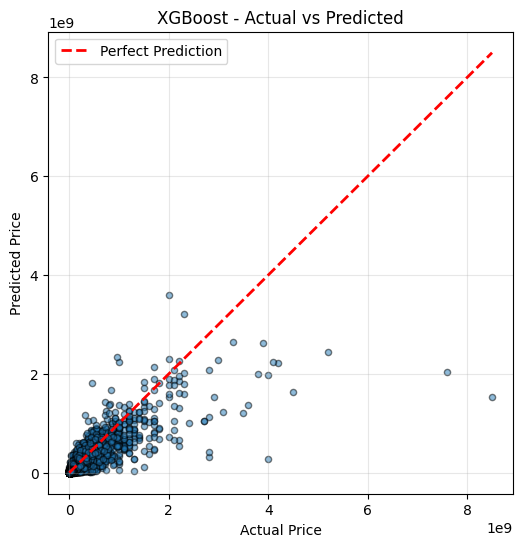

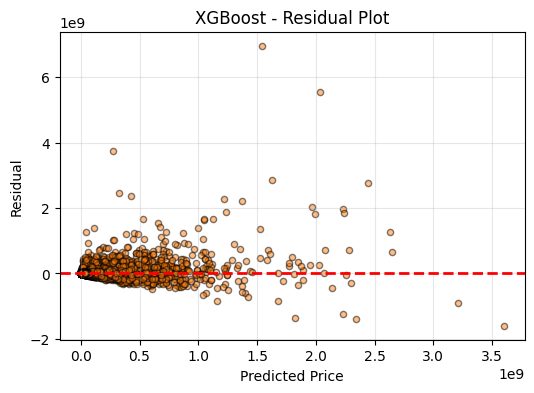

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

xgb_model = models["XGBoost_GPU"]

test_pred_log = xgb_model.predict(X_test)

y_test = np.expm1(np.asarray(y_test_log)).flatten()
y_pred = np.expm1(test_pred_log).flatten()

# Residual
residuals = y_test - y_pred
abs_pct_error = np.abs((y_test - y_pred) / (y_test + 1e-8)) * 100

# =========================
# Plot 1: Actual vs Predicted
# =========================
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='tab:blue', edgecolors='k', s=20)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost - Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# Plot 2: Residual Plot
# =========================
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5, color='tab:orange', edgecolors='k', s=20)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("XGBoost - Residual Plot")
plt.grid(True, alpha=0.3)
plt.show()



In [33]:
import joblib

xgb_model = models["XGBoost_GPU"]
joblib.dump(xgb_model, "xgboost_house_price.pkl")


['xgboost_house_price.pkl']